In [23]:
#using Pkg
#ENV["GRDIR"]=""
#Pkg.build("GR")

   Building GR → `~/.julia/packages/GR/oiZD3/deps/build.log`


In [1]:
using Plots
using Turing
using StatsPlots

┌ Info: Precompiling Plots [91a5bcdd-55d7-5caf-9e0b-520d859cae80]
└ @ Base loading.jl:1278
┌ Info: Precompiling Turing [fce5fe82-541a-59a6-adf8-730c64b5f9a0]
└ @ Base loading.jl:1278
┌ Info: Precompiling StatsPlots [f3b207a7-027a-5e70-b257-86293d7955fd]
└ @ Base loading.jl:1278


In [2]:
dx_measured = Float64[25.94, 38.84, 52.81, 45.54, 17.24]
t_measured  = Float64[ 3.91,  4.57,  5.43,  4.85,  3.15]

5-element Array{Float64,1}:
 3.91
 4.57
 5.43
 4.85
 3.15

In [3]:
@model gravity_uniform(t_final, x_final, theta) = begin
    g ~ Uniform(0, 10)
    mu = g .* (t_final .* t_final ./ 2)
    N = length(t_final)
    for n in 1:N
        x_final[n] ~ Normal(mu[n], 10)
    end
end

(::DynamicPPL.ModelGen{(:t_final, :x_final, :theta),var"###gravity_uniform#288",NamedTuple{(),Tuple{}}}) (generic function with 1 method)

In [4]:
ITERS = 10000
EPS = 0.05
TAU = 10

10

In [5]:
theta = 45
chainuniform = sample(gravity_uniform(t_measured, dx_measured, theta),
                      HMC(EPS, TAU),
                      ITERS,
                      progress=false)

Object of type Chains, with data of type 10000×10×1 Array{Real,3}

Iterations        = 1:10000
Thinning interval = 1
Chains            = 1
Samples per chain = 10000
internals         = acceptance_rate, hamiltonian_energy, hamiltonian_energy_error, is_accept, log_density, lp, n_steps, nom_step_size, step_size
parameters        = g

2-element Array{ChainDataFrame,1}

Summary Statistics
. Omitted printing of 1 columns
│ Row │ parameters │ mean    │ std      │ naive_se   │ mcse       │ ess     │
│     │ Symbol     │ Float64 │ Float64  │ Float64    │ Float64    │ Any     │
├─────┼────────────┼─────────┼──────────┼────────────┼────────────┼─────────┤
│ 1   │ g          │ 3.65706 │ 0.432945 │ 0.00432945 │ 0.00110949 │ 12518.1 │

Quantiles

│ Row │ parameters │ 2.5%    │ 25.0%   │ 50.0%   │ 75.0%   │ 97.5%   │
│     │ Symbol     │ Float64 │ Float64 │ Float64 │ Float64 │ Float64 │
├─────┼────────────┼─────────┼─────────┼─────────┼─────────┼─────────┤
│ 1   │ g          │ 2.81575 │ 3.3579  │ 3.6

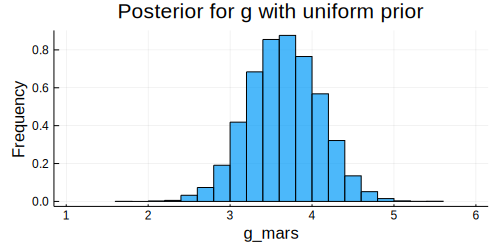

In [6]:
histogram(chainuniform[:g], xlim=[1, 6], legend=false, normalized=true)
xlabel!("g_mars")
title!("Posterior for g with uniform prior")

In [13]:
@model gravity_normal(t_final, x_final, theta) = begin
    N = length(t_final) 
    g ~ Normal(6, 2)
    mu = g .* (t_final.^2 ./ 2)
    for n in 1:N
        x_final[n] ~ Normal(mu[n], 3)
    end
end

(::DynamicPPL.ModelGen{(:t_final, :x_final, :theta),var"###gravity_normal#355",NamedTuple{(),Tuple{}}}) (generic function with 1 method)

In [14]:
chainnormal = sample(gravity_normal(t_measured, dx_measured, theta),
                     HMC(EPS, TAU),
                     ITERS,
                     progress=false)

Object of type Chains, with data of type 10000×10×1 Array{Real,3}

Iterations        = 1:10000
Thinning interval = 1
Chains            = 1
Samples per chain = 10000
internals         = acceptance_rate, hamiltonian_energy, hamiltonian_energy_error, is_accept, log_density, lp, n_steps, nom_step_size, step_size
parameters        = g

2-element Array{ChainDataFrame,1}

Summary Statistics
. Omitted printing of 1 columns
│ Row │ parameters │ mean    │ std      │ naive_se   │ mcse        │ ess     │
│     │ Symbol     │ Float64 │ Float64  │ Float64    │ Float64     │ Any     │
├─────┼────────────┼─────────┼──────────┼────────────┼─────────────┼─────────┤
│ 1   │ g          │ 3.66724 │ 0.128725 │ 0.00128725 │ 0.000558245 │ 15848.3 │

Quantiles

│ Row │ parameters │ 2.5%    │ 25.0%   │ 50.0%   │ 75.0%   │ 97.5%   │
│     │ Symbol     │ Float64 │ Float64 │ Float64 │ Float64 │ Float64 │
├─────┼────────────┼─────────┼─────────┼─────────┼─────────┼─────────┤
│ 1   │ g          │ 3.41552 │ 3.58349 │

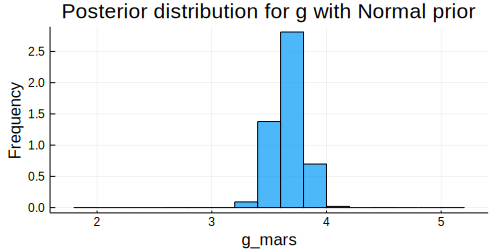

In [15]:
histogram(chainnormal[:g], legend=false, normalized=true)
xlabel!("g_mars")
title!("Posterior distribution for g with Normal prior")